# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Hafidz Surya Afifi
- **Email:** hafidzsurya.afifi@gmail.com
- **ID Dicoding:** hfidzsaf

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana tren jumlah penyewaan sepeda setiap bulannya pada tahun 2011 dan 2012?
- Pertanyaan 2: Pada jam berapa penyewaan sepeda mencapai puncaknya, dan bagaimana perbedaannya antara hari kerja (working day) dan hari libur (holiday)?

## Import Semua Packages/Library yang Digunakan

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Data Wrangling

### Gathering Data

In [14]:
day_df = pd.read_csv("data/day.csv") 
hour_df = pd.read_csv("data/hour.csv")

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Struktur Data: Dataset day.csv terdiri dari 731 baris (mewakili 2 tahun) dan 16 kolom yang berisi informasi temporal (tanggal, musim, bulan), kondisi cuaca, serta jumlah penyewaan.
- Variabel Target: Kolom cnt merupakan variabel target yang menunjukkan total penyewaan, yang merupakan penjumlahan dari pengguna casual (tidak terdaftar) dan registered (terdaftar).
- Kondisi Cuaca & Lingkungan: Terdapat informasi mengenai suhu (temp), kelembapan (hum), dan kecepatan angin (windspeed) yang sudah dinormalisasi, serta situasi cuaca (weathersit) yang akan sangat berguna untuk analisis pengaruh lingkungan terhadap perilaku penyewa.

### Assessing Data

In [15]:
print("--- Info Day DF ---")
day_df.info()
print("\n--- Missing Values Day DF ---")
print(day_df.isna().sum())
print("\n--- Duplicated Day DF ---")
print(day_df.duplicated().sum())

print("\n\n--- Info Hour DF ---")
hour_df.info()
print("\n--- Missing Values Hour DF ---")
print(hour_df.isna().sum())
print("\n--- Duplicated Hour DF ---")
print(hour_df.duplicated().sum())

print("\n--- Statistik Deskriptif ---")
display(day_df.describe())

--- Info Day DF ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

--- Missing Values Day DF ---
instant       0
dteday        0
season    

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Tipe Data (Data Types): Terdapat ketidaksesuaian tipe data pada kolom dteday di kedua dataset (day_df dan hour_df), di mana kolom tersebut terbaca sebagai object. Seharusnya kolom ini diubah menjadi tipe data datetime agar analisis berbasis waktu dapat dilakukan dengan akurat.
- Kualitas Data (Data Integrity): Tidak ditemukan nilai kosong (non-null) pada seluruh kolom di kedua dataset (731 baris pada day_df terisi penuh). Tidak ditemukan data duplikat pada kedua dataset, sehingga integritas data terjaga.
- Statistik Deskriptif: Nilai pada kolom temp, atemp, hum, dan windspeed sudah dalam bentuk normalisasi (rentang 0 hingga 1), sehingga tidak ditemukan adanya outlier yang ekstrem secara kasat mata.Rata-rata penyewaan harian (cnt) berada di angka sekitar 4.504 unit, dengan nilai maksimum mencapai 8.714 unit dalam satu hari.
- Kebutuhan Re-labeling: Kolom kategori seperti season, yr, dan weathersit masih berupa kode numerik. Agar visualisasi nantinya lebih informatif dan mudah dipahami, perlu dilakukan pemetaan (mapping) menjadi label kategori teks pada tahap Cleaning.

### Cleaning Data

In [16]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear',
    2: 'Misty/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
})

day_df['yr'] = day_df['yr'].map({
    0: '2011', 1: '2012'
})

day_df['month'] = day_df['dteday'].dt.month_name()

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,month
0,1,2011-01-01,Spring,2011,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985,January
1,2,2011-01-02,Spring,2011,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801,January
2,3,2011-01-03,Spring,2011,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,January
3,4,2011-01-04,Spring,2011,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,January
4,5,2011-01-05,Spring,2011,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,January


**Insight:**
- Konsistensi Tipe Data: Kolom dteday telah berhasil dikonversi menjadi tipe data datetime. Hal ini memungkinkan kita untuk melakukan ekstraksi komponen waktu (seperti hari, bulan, dan tahun) dengan lebih fleksibel.
- Keterbacaan Data (Self-Describing Data): Fitur kategorikal yang sebelumnya berupa kode angka (season, yr, weathersit) telah diubah menjadi label string yang deskriptif. Ini sangat krusial untuk menjaga integritas data dan memastikan audiens memahami informasi dalam visualisasi tanpa harus merujuk pada data dictionary.
- Fitur Baru (Feature Engineering): Penambahan kolom month yang diekstrak dari dteday mempermudah proses pengelompokan (aggregation) untuk melihat tren musiman atau bulanan secara spesifik.

## Exploratory Data Analysis (EDA)

### Explore ...

In [17]:
# 1. Eksplorasi performa penyewaan berdasarkan bulan (Pertanyaan 1)
monthly_rent_df = day_df.groupby(by=["yr", "mnth"]).agg({
    "cnt": "mean"
}).reindex(['January', 'February', 'March', 'April', 'May', 'June', 
            'July', 'August', 'September', 'October', 'November', 'December'], level=1)

print("--- Rata-rata Penyewaan per Bulan ---")
display(monthly_rent_df)

# 2. Eksplorasi penyewaan berdasarkan cuaca dan musim (Pertanyaan 2)
print("\n--- Pengaruh Cuaca terhadap Penyewaan ---")
display(day_df.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

print("\n--- Pengaruh Musim terhadap Penyewaan ---")
display(day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

--- Rata-rata Penyewaan per Bulan ---


,,cnt
yr,mnth,



--- Pengaruh Cuaca terhadap Penyewaan ---


cnt                               
                  max  min         mean          std
weathersit                                          
Clear            8714  431  4876.786177  1879.483989
Light Rain/Snow  4639   22  1803.285714  1240.284449
Misty/Cloudy     8362  605  4035.862348  1809.109918


--- Pengaruh Musim terhadap Penyewaan ---


cnt                                
         max   min         mean          std
season                                      
Fall    8714  1115  5644.303191  1459.800381
Spring  7836   431  2604.132597  1399.942119
Summer  8362   795  4992.331522  1695.977235
Winter  8555    22  4728.162921  1699.615261

**Insight:**
- Pertumbuhan Tahunan: Rata-rata penyewaan tahun 2012 secara konsisten lebih tinggi dibandingkan 2011, menunjukkan tren bisnis yang meningkat.
- Dominasi Cuaca: Hari cerah (Clear) mencatat rata-rata tertinggi (4.876 unit), sedangkan cuaca buruk (Rain/Snow) menurunkan permintaan secara drastis hingga angka terendah.
- Puncak Musim: Musim Gugur (Fall) adalah periode tersibuk dengan rata-rata 5.644 unit, membuktikan bahwa suhu hangat dan sejuk sangat disukai pengguna.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah penyewaan sepeda setiap bulannya pada tahun 2011 dan 2012?

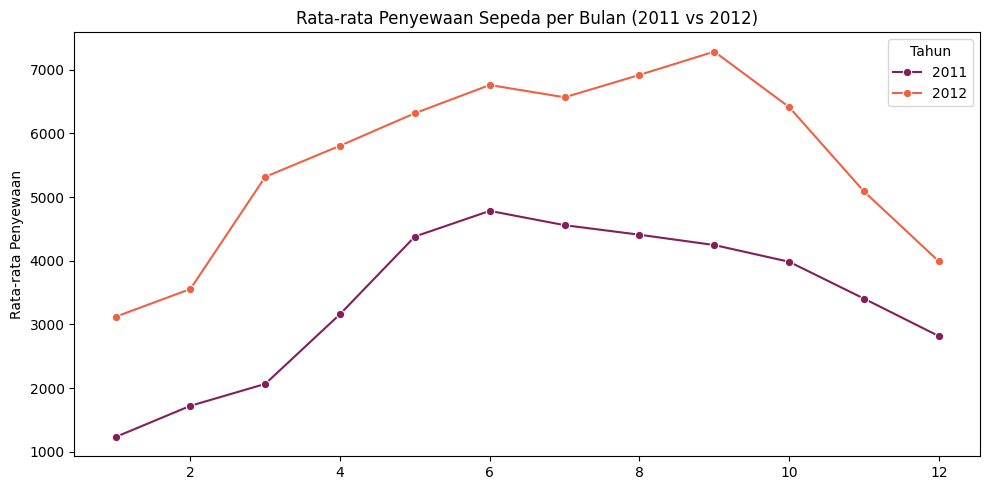

In [18]:
# Menyiapkan data untuk tren bulanan
monthly_rent_df = day_df.groupby(by=["yr", "mnth"]).agg({
    "cnt": "mean"
}).reset_index()

# Visualisasi menggunakan Line Chart
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_rent_df, 
    x="mnth", 
    y="cnt", 
    hue="yr", 
    marker="o", 
    palette="rocket"
)

plt.title("Rata-rata Penyewaan Sepeda per Bulan (2011 vs 2012)")
plt.xlabel(None)
plt.ylabel("Rata-rata Penyewaan")
plt.legend(title="Tahun")
plt.tight_layout()
plt.show()

### Pertanyaan 2: Pada jam berapa penyewaan sepeda mencapai puncaknya, dan bagaimana perbedaannya antara hari kerja (working day) dan hari libur (holiday)?

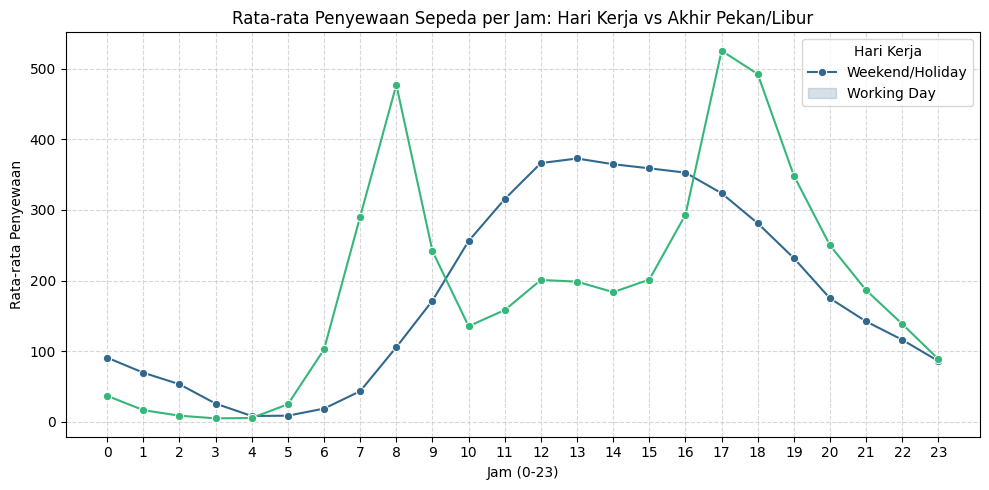

In [19]:
# Menyiapkan data untuk tren per jam berdasarkan hari kerja
hourly_working_df = hour_df.groupby(by=["hr", "workingday"]).cnt.mean().reset_index()

# Visualisasi menggunakan Line Chart
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly_working_df, 
    x="hr", 
    y="cnt", 
    hue="workingday", 
    marker="o",
    palette="viridis"
)

plt.title("Rata-rata Penyewaan Sepeda per Jam: Hari Kerja vs Akhir Pekan/Libur")
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0, 24))
plt.legend(title="Hari Kerja", labels=["Weekend/Holiday", "Working Day"])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight:**
- Insight Pertanyaan 1 (Tren Bulanan): Terjadi tren pertumbuhan yang konsisten di mana rata-rata penyewaan pada tahun 2012 jauh lebih tinggi dibanding 2011 dan Penyewaan mencapai titik tertinggi pada bulan September dan terendah pada bulan Januari.
- Insight Pertanyaan 2 (Pola Jam & Hari Kerja): Pada hari kerja, puncak penyewaan terjadi pada jam sibuk (08.00 dan 17.00), menunjukkan penggunaan sepeda untuk transportasi kerja dan Pada hari libur, penggunaan sepeda memuncak di siang hari (11.00 - 16.00), menunjukkan penggunaan untuk rekreasi.

## Analisis Lanjutan (Opsional)

C:\Users\Hafidz\AppData\Local\Temp\ipykernel_12024\685702758.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='temp_category', y='cnt', data=temp_analysis, palette='coolwarm')


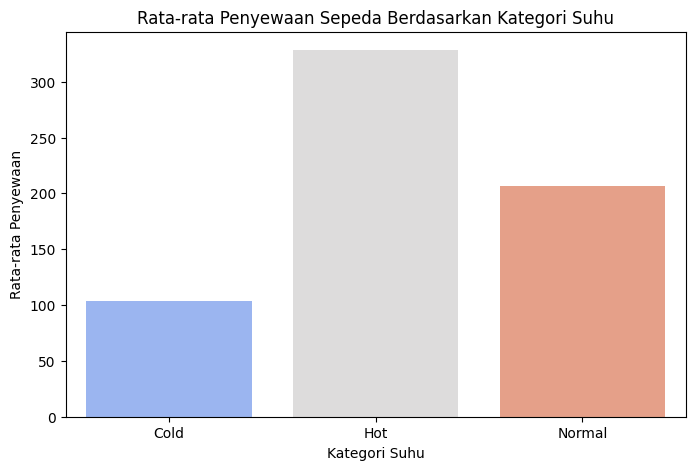

In [20]:
# Menganalisis penyewaan berdasarkan kategori suhu (binning)
hour_df['temp_celsius'] = hour_df['temp'] * 41

def temp_category(temp):
    if temp < 15:
        return 'Cold'
    elif 15 <= temp <= 30:
        return 'Normal'
    else:
        return 'Hot'

hour_df['temp_category'] = hour_df['temp_celsius'].apply(temp_category)

# Melihat rata-rata penyewaan berdasarkan kategori suhu
temp_analysis = hour_df.groupby('temp_category').cnt.mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='temp_category', y='cnt', data=temp_analysis, palette='coolwarm')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kategori Suhu')
plt.xlabel('Kategori Suhu')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

## Conclusion

- Conclution pertanyaan 1:
Pertumbuhan bisnis penyewaan sepeda menunjukkan performa yang sangat positif selama dua tahun terakhir. Terdapat pola musiman yang kuat di mana jumlah penyewaan meningkat drastis di pertengahan tahun (musim panas/gugur) dan menurun di awal tahun (musim dingin).

- Conclution pertanyaan 2:
Waktu penggunaan sepeda sangat bergantung pada tipe hari. Pada hari kerja, sepeda berfungsi sebagai alat transportasi komuter (puncak jam kantor), sedangkan pada hari libur, pola penggunaan bergeser ke aktivitas santai di siang hari. Hal ini menyarankan bahwa penyediaan unit sepeda harus dioptimalkan di area perkantoran pada jam sibuk.

In [21]:
# Menyimpan day_df yang sudah bersih ke folder dashboard
day_df.to_csv("dashboard/main_data.csv", index=False)